# Lab 8 — Navigation World Model: memory- and model-driven navigation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab08_navigation_world_model/notebook_en.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 8**

In all the previous labs the agent could read the **global state** (with noise): the ball's coordinates in Labs 0/4 were simply given. In real navigation, a robot only sees a **local view** at each moment, and the goal is hidden in regions it has never seen. In a self-implemented 2D grid world, this lab answers one question: **how much "internal state" does navigation actually need?**

We implement and compare three agents head to head (the core teaching point):

1. **Reactive Agent**: looks only at the current 5×5 observation, greedy + an inertial random walk, no memory at all;
2. **Agent with Memory**: maintains a global **occupancy map** that fills in over time (spatial memory), and does **BFS** planning and frontier exploration on the remembered map;
3. **Agent with World Model**: adds a **learned forward model** on top of memory that predicts "what the local observation will look like after an action", so planning can **extend into regions it has not seen yet** (planning in imagination).

The core chain: **Observation → State Estimation (odometry) → Memory / Map → World Model → Planning → Action**.

## 1. Motivation: why can't navigation rely only on "what I see right now"?

**Why this matters:** the agent's observation in the grid world is a 5×5 window centered on itself, a textbook case of **partial observability** (POMDP). The current observation does not tell you "where I came from, what was on the other side of that fork, or which direction the goal is". A reactive agent that decides from the current frame alone **goes round in circles** in corners and corridors, because nothing lets it remember "I've been here".

The three keywords of this lab map onto three layers of concepts in the course:

- **State / State Estimation**: the true state (grid + pose + goal) is invisible to the agent; the agent estimates its pose with **odometry** (integrating its own actions + collision feedback), which is the prerequisite for "pinning" observations onto a map;
- **Memory / Spatial Representation**: an allocentric (world-frame) occupancy map is the plainest form of spatial memory: what has been seen is known. It stops the agent from re-exploring, and makes **graph planning** such as BFS/A* possible;
- **World Model**: memory can only tell you what you **have seen**; a model lets you make informed guesses about what you **have not seen**. With it, the planner can cut through unknown areas and explore first in directions the model predicts are open. The price is **model error**, and when the statistics of the world change (**OOD**), this confidence turns into failure.

## 2. Setup

**Why this cell exists:** apart from the scientific stack, only `imageio` (for writing GIFs) is needed; Colab has torch / numpy / matplotlib preinstalled, and the cell below installs anything missing so the notebook behaves the same on Colab and locally.

In [1]:
# @title setup
import sys, subprocess

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg in ["imageio"]:
    ensure(pkg)

import os, time, heapq
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import imageio.v2 as imageio
import torch
import torch.nn as nn
from IPython.display import Image, display

%matplotlib inline
os.makedirs("assets", exist_ok=True)
torch.manual_seed(0)
np.random.seed(0)
device = "cpu"  # the whole lab runs on CPU
T0 = time.time()
print("torch", torch.__version__, "| numpy", np.__version__, "| device", device)

torch 2.14.0+cu130 | numpy 2.4.6 | device cpu


## 3. Environment & Dataset

### 3.1 Environment: a partially observable 2D grid world

**Design points (all hand-written, no gym dependency):**

- **World**: a 25×25 grid with walls around the border and a number of random rectangular obstacles inside; start and goal are sampled at random (guaranteed connected, Manhattan distance ≥ 20);
- **Observation**: a **5×5 window** centered on the agent (`view_radius=2`), with values `{0 free, 1 wall, 2 goal}`; the goal only "exists" once it enters the field of view;
- **Actions**: move up / down / left / right; hitting a wall leaves the agent in place;
- **Odometry feedback**: `step()` returns `info["moved"]` (whether the agent really moved this step), the agent's only proprioception for state estimation. Note that the env **never returns global coordinates**; `env.pos` is only for evaluation and plotting, and the agent is forbidden to access it.

In [2]:
UP, DOWN, LEFT, RIGHT = 0, 1, 2, 3
DELTAS = [(-1, 0), (1, 0), (0, -1), (0, 1)]
ACT_NAMES = ["up", "down", "left", "right"]
UNKNOWN, FREE, WALL = -1, 0, 1   # memory map values; UNKNOWN only exists in the agent's head
STAY = 4                          # "stay in place" action, only used to query the world model

def _reachable(grid, start, goal):
    """BFS flood: can start reach goal (through free cells only)?"""
    H, W = grid.shape
    seen = np.zeros((H, W), bool); seen[start] = True
    stack = [tuple(start)]
    while stack:
        r, c = stack.pop()
        if (r, c) == tuple(goal):
            return True
        for dr, dc in DELTAS:
            nr, nc = r + dr, c + dc
            if 0 <= nr < H and 0 <= nc < W and grid[nr, nc] == 0 and not seen[nr, nc]:
                seen[nr, nc] = True; stack.append((nr, nc))
    return False

def generate_map(H, W, n_rects, rng, min_dist, max_tries=300):
    """map with random rectangular obstacles; rejection-sample until start/goal are connected and far enough apart."""
    for _ in range(max_tries):
        grid = np.zeros((H, W), dtype=np.int64)
        grid[0, :] = grid[-1, :] = 1; grid[:, 0] = grid[:, -1] = 1
        for _ in range(n_rects):
            h, w = rng.integers(2, 5), rng.integers(2, 5)
            r, c = rng.integers(1, H - h - 1), rng.integers(1, W - w - 1)
            grid[r:r + h, c:c + w] = 1
        frees = np.argwhere(grid == 0)
        i, j = rng.choice(len(frees), size=2, replace=False)
        start, goal = tuple(frees[i]), tuple(frees[j])
        if abs(start[0] - goal[0]) + abs(start[1] - goal[1]) < min_dist:
            continue
        if _reachable(grid, start, goal):
            return grid, start, goal
    raise RuntimeError("map generation failed")

class GridNavEnv:
    """2D grid navigation with partial observability.

    reset() / step(action) -> obs, done, info
      obs  : (2R+1, 2R+1) window centered on the agent, values {0 free, 1 wall, 2 goal}
      info : {"moved": bool, ...}  — odometry feedback, the agent's only pose cue
    Global coordinates (env.pos) are hidden state, available only for evaluation/visualization.
    """
    def __init__(self, grid, start, goal, view_radius=2, max_steps=400):
        self.grid = grid
        self.start, self.goal = tuple(start), tuple(goal)
        self.R, self.max_steps = view_radius, max_steps
        self.H, self.W = grid.shape

    def reset(self):
        self.pos, self.t = self.start, 0
        return self._obs()

    def _obs(self):
        R = self.R
        win = np.ones((2 * R + 1, 2 * R + 1), dtype=np.int64)  # out of bounds counts as wall
        r0, c0 = self.pos
        for i in range(2 * R + 1):
            for j in range(2 * R + 1):
                gr, gc = r0 - R + i, c0 - R + j
                if 0 <= gr < self.H and 0 <= gc < self.W:
                    win[i, j] = 2 if (gr, gc) == self.goal else self.grid[gr, gc]
        return win

    def step(self, action):
        dr, dc = DELTAS[action]
        nr, nc = self.pos[0] + dr, self.pos[1] + dc
        moved = False
        if 0 <= nr < self.H and 0 <= nc < self.W and self.grid[nr, nc] == 0:
            self.pos = (nr, nc); moved = True
        self.t += 1
        done = (self.pos == self.goal) or (self.t >= self.max_steps)
        return self._obs(), done, {"moved": moved, "success": self.pos == self.goal}

### 3.2 Smoke test: the gap between "the whole world" and "what the agent sees"

The left plot is the **god's view** (which the agent never sees); the right plot is the 5×5 observation it actually gets. All the difficulty comes from the information gap between these two pictures.

map (25, 25) | start (np.int64(10), np.int64(16)) | goal (np.int64(1), np.int64(2)) | obs window (5, 5)
t=0  moved=True  (the agent sees only the window, not where it is)
t=1  moved=True  (the agent sees only the window, not where it is)
t=2  moved=True  (the agent sees only the window, not where it is)
t=3  moved=True  (the agent sees only the window, not where it is)


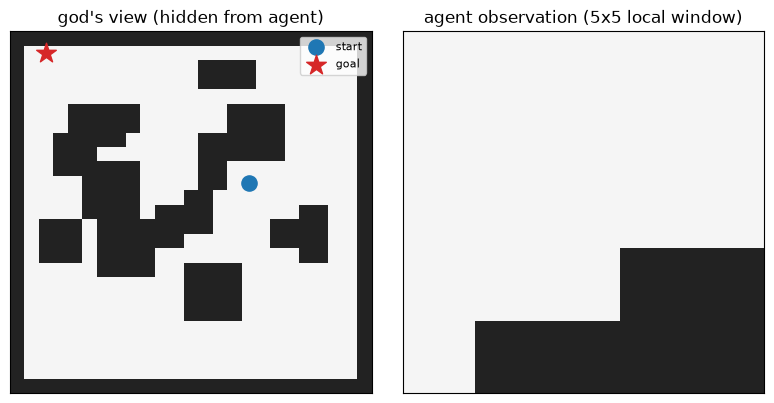

In [3]:
R_VIEW = 2
viz_rng = np.random.default_rng(7)
grid, start, goal = generate_map(25, 25, n_rects=14, rng=viz_rng, min_dist=20)
env = GridNavEnv(grid, start, goal, view_radius=R_VIEW, max_steps=300)
obs = env.reset()
print(f"map {grid.shape} | start {start} | goal {goal} | obs window {obs.shape}")
for t in range(4):
    obs, done, info = env.step(int(np.random.default_rng(t).integers(4)))
    print(f"t={t}  moved={info['moved']}  (the agent sees only the window, not where it is)")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(grid, cmap=mcolors.ListedColormap(["#f5f5f5", "#222222"]), origin="upper")
axes[0].scatter(*start[::-1], marker="o", c="#1f77b4", s=120, label="start")
axes[0].scatter(*goal[::-1], marker="*", c="#d62728", s=220, label="goal")
axes[0].set_title("god's view (hidden from agent)"); axes[0].legend(loc="upper right", fontsize=8)
axes[1].imshow(obs, cmap=mcolors.ListedColormap(["#f5f5f5", "#222222", "#2ca02c"]),
               origin="upper", vmin=0, vmax=2)
axes[1].set_title("agent observation (5x5 local window)")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig("assets/env_teaser.png", dpi=110); plt.show()

### 3.3 Dataset: preparing (window, action) → next window data for the forward model

**Why:** the world model has to learn transitions in observation space: **given the current local window and an action, predict the next local window**. Key design choices:

- When **the action is a move**, the next window is the shifted window, and the column/row of cells that newly enters the view **never appeared in the input**. The model has to "fill them in" from context (the local texture of obstacles). This is where the ability to "predict unseen regions" comes from;
- When **the action is STAY (a query)**, the next window = the current window itself, but during training the input window is randomly masked to `UNKNOWN` while the target stays the full ground truth. This teaches the model **map completion** (filling the unknown cells of the memory map with predicted occupancy);
- When the agent hits a wall it stays in place, so the target is the unmoved window; the data naturally contains "the wall blocks the way" transitions.

All of this data comes from **training maps** (with seeds different from the test maps later), by randomly sampling (position, action, mask) triples, without actually rolling out an agent.

In [4]:
def window_of(grid, r, c, R):
    """take the (2R+1)^2 window centered at (r,c); out of bounds is filled with wall. grid may contain UNKNOWN(-1)."""
    H, W = grid.shape
    out = np.ones((2 * R + 1, 2 * R + 1), dtype=np.int64)
    for i in range(2 * R + 1):
        for j in range(2 * R + 1):
            gr, gc = r - R + i, c - R + j
            if 0 <= gr < H and 0 <= gc < W:
                out[i, j] = grid[gr, gc]
    return out

def make_model_dataset(n_maps, samples_per_map, H=25, W=25, n_rects=14, R=2, seed=0):
    """returns X_win (N,5,5)∈{-1,0,1}, X_act (N,), Y (N,5,5)∈{0,1}."""
    rng = np.random.default_rng(seed)
    X_win, X_act, Y = [], [], []
    for _ in range(n_maps):
        g, _, _ = generate_map(H, W, n_rects, rng, min_dist=15)
        frees = np.argwhere(g == 0)
        for _ in range(samples_per_map):
            r, c = frees[rng.integers(len(frees))]
            a = int(rng.integers(5))  # includes the STAY query action
            dr, dc = DELTAS[a] if a < 4 else (0, 0)
            nr, nc = r + dr, c + dc
            if not (0 <= nr < H and 0 <= nc < W) or g[nr, nc] == 1:
                nr, nc = r, c  # hit a wall / out of bounds → stay in place
            win_in = window_of(g, r, c, R).astype(np.int64)
            mask = rng.random(win_in.shape) < rng.uniform(0.0, 0.6)  # simulate "incomplete memory"
            win_in[mask] = UNKNOWN
            X_win.append(win_in)
            X_act.append(a)
            Y.append(window_of(g, nr, nc, R).astype(np.int64))  # full ground truth
    return np.array(X_win), np.array(X_act), np.array(Y)

Xtr, Atr, Ytr = make_model_dataset(48, 400, R=R_VIEW, seed=0)
Xva, Ava, Yva = make_model_dataset(8, 400, R=R_VIEW, seed=999)
PRIOR_FREE = float((Ytr == FREE).mean())
print(f"train {Xtr.shape} | val {Xva.shape} | free-cell prior = {PRIOR_FREE:.3f}")
print(f"fraction of UNKNOWN in the inputs: {(Xtr == UNKNOWN).mean():.2f}(simulating partial memory)")

train (19200, 5, 5) | val (3200, 5, 5) | free-cell prior = 0.749
fraction of UNKNOWN in the inputs: 0.30(simulating partial memory)


## 4. Build the Model

Three components, all hand-written and visible:

### 4.1 State Estimation + Memory: `SpatialMemory`
The agent maintains a pose estimate with **odometry** (integrating actions + the `moved` collision feedback), then "pins" each 5×5 observation into an allocentric **occupancy map** (`UNKNOWN / FREE / WALL`). Once the goal has been seen, its coordinates are stored in memory permanently.

### 4.2 Planning primitives: BFS and Dijkstra
The memory agent runs BFS on a **conservative map** where "known free is passable, unknown counts as impassable"; the world model agent uses the model's predictions to estimate a **traversal cost** for unknown cells and runs Dijkstra on the "imagined map".

### 4.3 Forward Model: `ForwardModel`
A small MLP: input = 3-channel one-hot of the 5×5 window (UNKNOWN/FREE/WALL) + a one-hot action (4 moves + the STAY query); output = free/wall logits for every cell of the next window. It learns two things at once: **translation dynamics** + **occupancy prediction for unseen cells**.

In [5]:
class SpatialMemory:
    """Odometry pose estimate + allocentric occupancy map (spatial memory)."""
    def __init__(self, H, W, R):
        self.H, self.W, self.R = H, W, R
        self.reset((0, 0))

    def reset(self, start_pose):
        self.map = np.full((self.H, self.W), UNKNOWN, dtype=np.int64)
        self.pose = tuple(start_pose)   # pose estimate: pure odometry integration
        self.goal_pos = None            # once seen, the goal is remembered permanently

    def update(self, obs, action, moved):
        # --- state estimation: odometry (pose unchanged when hitting a wall) ---
        if action is not None and moved:
            dr, dc = DELTAS[action]
            self.pose = (self.pose[0] + dr, self.pose[1] + dc)
        # --- mapping: pin the local observation onto the global map ---
        R = self.R; r0, c0 = self.pose
        for i in range(2 * R + 1):
            for j in range(2 * R + 1):
                gr, gc = r0 - R + i, c0 - R + j
                if 0 <= gr < self.H and 0 <= gc < self.W:
                    v = obs[i, j]
                    if v == 2:
                        self.goal_pos = (gr, gc); self.map[gr, gc] = FREE
                    else:
                        self.map[gr, gc] = v

def bfs_next_action(passable, start, is_target):
    """BFS on the boolean passable map to the nearest target; returns the first action, or None if unreachable."""
    H, W = passable.shape
    prev = {tuple(start): None}
    q = deque([tuple(start)])
    target = None
    while q:
        cur = q.popleft()
        if cur != tuple(start) and is_target(cur):
            target = cur; break
        for dr, dc in DELTAS:
            nxt = (cur[0] + dr, cur[1] + dc)
            if 0 <= nxt[0] < H and 0 <= nxt[1] < W and passable[nxt] and nxt not in prev:
                prev[nxt] = cur; q.append(nxt)
    if target is None:
        return None
    while prev[target] != tuple(start):  # backtrack to the first step
        target = prev[target]
    return DELTAS.index((target[0] - start[0], target[1] - start[1]))

def dijkstra(cost, start):
    """weighted shortest path: returns the dist map and prev pointers (node -> (parent, action))."""
    H, W = cost.shape
    dist = np.full((H, W), np.inf); dist[tuple(start)] = 0.0
    prev = {}
    pq = [(0.0, tuple(start))]
    while pq:
        d, cur = heapq.heappop(pq)
        if d > dist[cur]:
            continue
        for a, (dr, dc) in enumerate(DELTAS):
            nxt = (cur[0] + dr, cur[1] + dc)
            if 0 <= nxt[0] < H and 0 <= nxt[1] < W and np.isfinite(cost[nxt]):
                nd = d + cost[nxt]
                if nd < dist[nxt]:
                    dist[nxt] = nd; prev[nxt] = (cur, a)
                    heapq.heappush(pq, (nd, nxt))
    return dist, prev

def first_action_to(prev, start, target):
    """backtrack along prev; returns the first action from start toward target."""
    start, node = tuple(start), tuple(target)
    if node == start or node not in prev:
        return None
    while node != start:
        parent, a = prev[node]
        if parent == start:
            return a
        node = parent
    return None

In [6]:
def encode_batch(win, act):
    """(N,5,5)∈{-1,0,1} windows + (N,) actions -> (N, 3*25+5) model input."""
    N = win.shape[0]
    x = np.zeros((N, 3, *win.shape[1:]), np.float32)
    x[:, 0] = (win == UNKNOWN); x[:, 1] = (win == FREE); x[:, 2] = (win == WALL)
    a = np.zeros((N, 5), np.float32); a[np.arange(N), act] = 1.0
    return np.concatenate([x.reshape(N, -1), a], axis=1)

class ForwardModel(nn.Module):
    """(local window, action) -> per-cell free/wall prediction of the next local window."""
    def __init__(self, R=2, hidden=128):
        super().__init__()
        self.R = R
        n = (2 * R + 1) ** 2
        self.net = nn.Sequential(
            nn.Linear(3 * n + 5, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2 * n),
        )

    def forward(self, x):
        n = (2 * self.R + 1) ** 2
        return self.net(x).view(-1, 2, n)  # logits: [N, {free,wall}, cells]

model = ForwardModel(R=R_VIEW).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"ForwardModel parameters: {n_params:,}(deliberately small: trains in seconds on CPU, with visible errors)")

ForwardModel parameters: 33,330(deliberately small: trains in seconds on CPU, with visible errors)


## 5. Train the Forward Model

**Why:** the model does not need to be perfect. It only needs to be **closer to the true statistics** than both "unknown means impassable" (the memory agent's assumption) and "treat all unknown as free" (blind optimism). We deliberately use a small model + small data so the prediction error stays visible, which is what makes the comparisons in Sections 6–8 instructive.

epoch  1/12  loss 0.5242
epoch  2/12  loss 0.3289
epoch  3/12  loss 0.2741


epoch  4/12  loss 0.2573


epoch  5/12  loss 0.2499
epoch  6/12  loss 0.2443
epoch  7/12  loss 0.2364


epoch  8/12  loss 0.2286
epoch  9/12  loss 0.2203
epoch 10/12  loss 0.2121


epoch 11/12  loss 0.2054
epoch 12/12  loss 0.1991


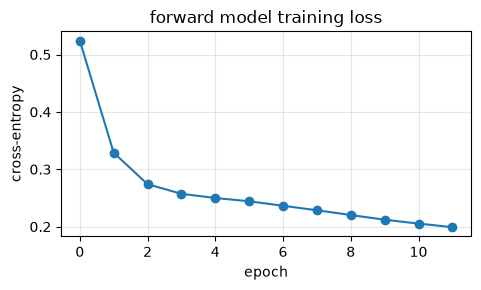

In [7]:
EPOCHS, BATCH, LR = 12, 512, 1e-3
Xt = torch.from_numpy(encode_batch(Xtr, Atr)).float()
Yt = torch.from_numpy(Ytr.reshape(len(Ytr), -1)).long()
Xv = torch.from_numpy(encode_batch(Xva, Ava)).float()
Yv = torch.from_numpy(Yva.reshape(len(Yva), -1)).long()

opt = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss()
losses = []
for ep in range(EPOCHS):
    model.train()
    perm = torch.randperm(len(Xt))
    ep_loss, nb_ = 0.0, 0
    for i in range(0, len(Xt), BATCH):
        idx = perm[i:i + BATCH]
        loss = loss_fn(model(Xt[idx]), Yt[idx])
        opt.zero_grad(); loss.backward(); opt.step()
        ep_loss += loss.item(); nb_ += 1
    losses.append(ep_loss / nb_)
    print(f"epoch {ep+1:2d}/{EPOCHS}  loss {losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(losses, "o-"); ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy")
ax.set_title("forward model training loss"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("assets/training_loss.png", dpi=110); plt.show()

In [8]:
# model quality check: overall cell accuracy vs completion accuracy on "cells not visible in the input"
model.eval()
with torch.no_grad():
    pred = model(Xv).argmax(dim=1)  # (N, 25), 0=free 1=wall
acc_all = (pred == Yv).float().mean().item()
unknown_flat = (Xva.reshape(len(Xva), -1) == UNKNOWN)
acc_inpaint = (pred[unknown_flat] == Yv[unknown_flat]).float().mean().item()
base_rate = max(PRIOR_FREE, 1 - PRIOR_FREE)
print(f"held-out overall cell accuracy:       {acc_all:.3f}")
print(f"held-out unseen-cell completion acc.: {acc_inpaint:.3f}  (majority-class baseline ≈ {base_rate:.3f})")
print("→ on 'never-seen cells' the model's guesses are much better than chance but far from perfect: this is where model error comes from.")

held-out overall cell accuracy:       0.926
held-out unseen-cell completion acc.: 0.893  (majority-class baseline ≈ 0.749)
→ on 'never-seen cells' the model's guesses are much better than chance but far from perfect: this is where model error comes from.


## 6. Visualize: how well does the model "imagine"?

### 6.1 Predicted vs Actual: the next local observation

One sample per row: **input window** (gray = UNKNOWN, i.e. cells memory has not seen yet) → **the model's predicted next window** (a heat map of free probability) → **the actual next window**. Look at the edge that newly enters the view: the model is "filling in" from the texture of rectangular obstacles.

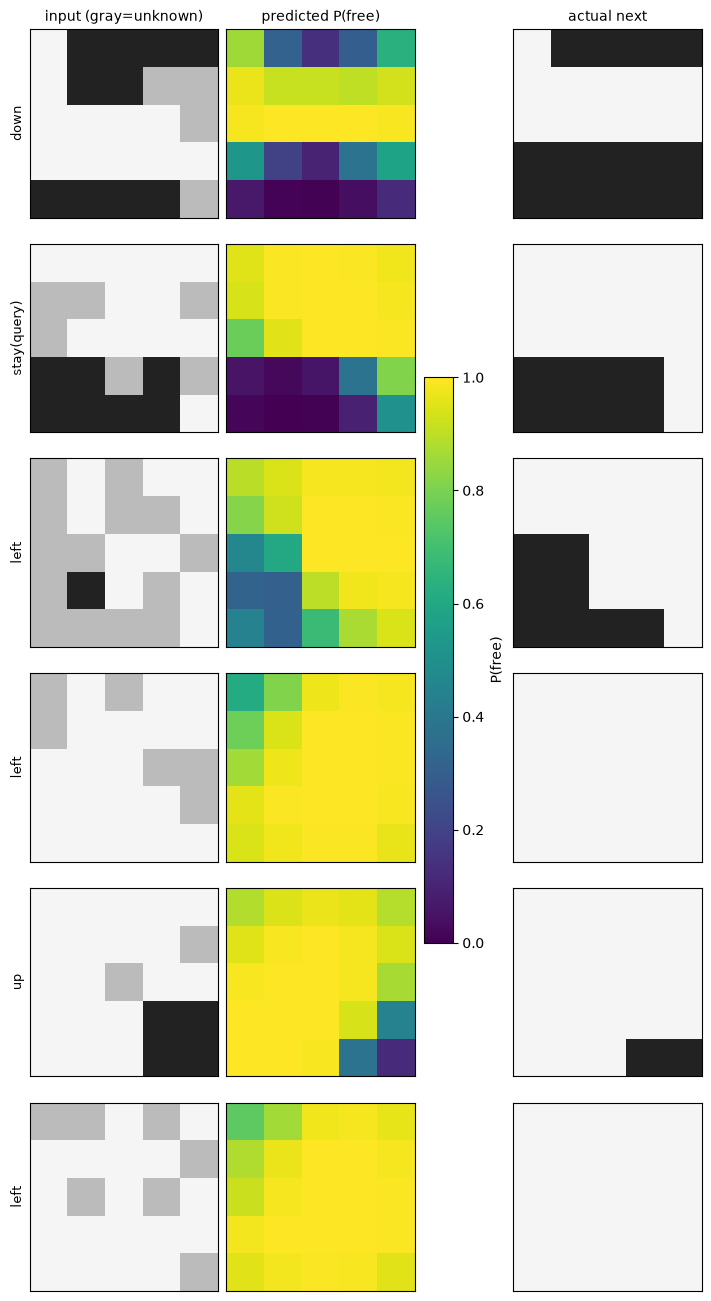

In [9]:
model.eval()
R = R_VIEW
idx_pool = np.where((Xva.reshape(len(Xva), -1) == UNKNOWN).any(axis=1))[0]
show = np.random.default_rng(3).choice(idx_pool, size=6, replace=False)
with torch.no_grad():
    logits = model(torch.from_numpy(encode_batch(Xva[show], Ava[show])).float())
p_free = torch.softmax(logits, dim=1)[:, 0, :].numpy().reshape(-1, 2 * R + 1, 2 * R + 1)

cmap_in = mcolors.ListedColormap(["#bbbbbb", "#f5f5f5", "#222222"])  # UNKNOWN/FREE/WALL
fig, axes = plt.subplots(6, 3, figsize=(7, 13), constrained_layout=True)
for k in range(6):
    axes[k, 0].imshow(Xva[show[k]] + 1, cmap=cmap_in, vmin=0, vmax=2)
    axes[k, 0].set_ylabel(ACT_NAMES[Ava[show[k]]] if Ava[show[k]] < 4 else "stay(query)",
                          fontsize=9)
    im = axes[k, 1].imshow(p_free[k], cmap="viridis", vmin=0, vmax=1)
    axes[k, 2].imshow(Yva[show[k]], cmap=mcolors.ListedColormap(["#f5f5f5", "#222222"]),
                      vmin=0, vmax=1)
    for j, t in enumerate(["input (gray=unknown)", "predicted P(free)", "actual next"]):
        axes[k, j].set_xticks([]); axes[k, j].set_yticks([])
        if k == 0: axes[k, j].set_title(t, fontsize=10)
fig.colorbar(im, ax=axes[:, 1], shrink=0.6, label="P(free)")
plt.savefig("assets/model_predictions.png", dpi=110); plt.show()

### 6.2 The map fills in: how spatial memory grows

Run the **memory agent** for one episode and record its occupancy map at every step. Left: the whole world + the true trajectory; right: the map in the agent's head (gray = unknown). You can see how **frontier exploration** pushes the gray back bit by bit, and how, the moment the goal is seen, planning switches instantly from "explore" to "head straight for the goal".

memory agent: success=True in 79 steps, 41 frames


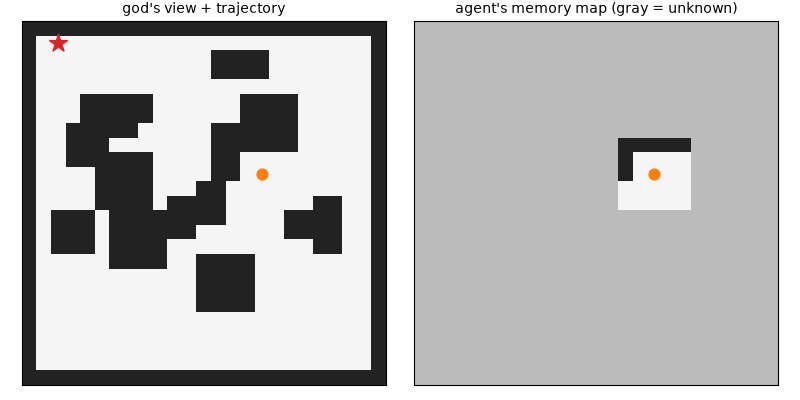

In [10]:
def render_memory_frame(env, mem, traj):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(env.grid, cmap=mcolors.ListedColormap(["#f5f5f5", "#222222"]))
    axes[0].scatter(*env.goal[::-1], marker="*", c="#d62728", s=180)
    axes[0].set_title("god's view + trajectory", fontsize=10)
    axes[1].imshow(mem.map + 1, cmap=mcolors.ListedColormap(["#bbbbbb", "#f5f5f5", "#222222"]),
                   vmin=0, vmax=2)
    axes[1].set_title("agent's memory map (gray = unknown)", fontsize=10)
    for ax in axes:
        if len(traj) > 1:
            tr = np.array(traj)
            ax.plot(tr[:, 1], tr[:, 0], "-", c="#1f77b4", lw=1.2, alpha=0.8)
        ax.scatter(*traj[-1][::-1], marker="o", c="#ff7f0e", s=60)
        ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout()
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
    plt.close(fig)
    return frame

# define the memory agent first (Section 7 formally introduces and compares the three agents)
class MemoryAgent:
    """maintains a global occupancy map; if the goal is known, BFS straight to it, otherwise BFS to the nearest frontier to explore."""
    def __init__(self, H, W, R=2, seed=0):
        self.mem = SpatialMemory(H, W, R)
        self.rng = np.random.default_rng(seed)

    def reset(self, start): self.mem.reset(start)
    def update(self, obs, action, moved): self.mem.update(obs, action, moved)

    def _is_frontier(self, cell):
        r, c = cell
        if self.mem.map[r, c] != FREE:
            return False
        for dr, dc in DELTAS:
            nr, nc = r + dr, c + dc
            if 0 <= nr < self.mem.H and 0 <= nc < self.mem.W and self.mem.map[nr, nc] == UNKNOWN:
                return True
        return False

    def act(self):
        m, pose = self.mem.map, self.mem.pose
        passable = (m == FREE)
        if self.mem.goal_pos is not None:
            a = bfs_next_action(passable, pose, lambda c: c == self.mem.goal_pos)
            if a is not None:
                return a
        a = bfs_next_action(passable, pose, self._is_frontier)  # explore the nearest frontier
        if a is not None:
            return a
        return int(self.rng.integers(4))  # fallback (should never be reached in theory)

gif_env = GridNavEnv(grid, start, goal, view_radius=R_VIEW, max_steps=300)
gif_agent = MemoryAgent(25, 25, R=R_VIEW, seed=0)
obs = gif_env.reset()
gif_agent.reset(gif_env.start); gif_agent.update(obs, None, False)
traj = [gif_env.pos]; frames = [render_memory_frame(gif_env, gif_agent.mem, traj)]
while True:
    a = gif_agent.act()
    obs, done, info = gif_env.step(a)
    gif_agent.update(obs, a, info["moved"])
    traj.append(gif_env.pos)
    if gif_env.t % 2 == 0 or done:
        frames.append(render_memory_frame(gif_env, gif_agent.mem, traj))
    if done:
        break
imageio.mimsave("assets/map_filling.gif", frames, duration=0.08)
print(f"memory agent: success={info['success']} in {gif_env.t} steps, {len(frames)} frames")
display(Image(filename="assets/map_filling.gif"))

## 7. Evaluate: three agents head to head

**Three agents on the same batch of test maps (a paired comparison):**

1. **Reactive**: no memory. If the goal appears in the window it approaches greedily; otherwise it keeps wandering with the inertia of its last direction (changing direction only when it hits a wall). It retraces old paths and oscillates in corners, because nothing tells it "I've been here";
2. **Memory**: `SpatialMemory` + conservative BFS: unknown cells count as impassable, and while the goal is unseen it explores the nearest frontier;
3. **World Model**: calls the forward model on top of memory:
   - predicts `P(free)` for unknown cells, builds an **imagined cost map** `cost = 1 + β·(1 − P(free))`, and runs **Dijkstra** on it. Paths may cut through unknown areas the model believes are open (shortcuts) instead of waiting for exploration;
   - while the goal is unknown, frontiers are scored by `imagined distance − gain_w · predicted number of newly visible free cells` (an embryonic next-best-view), preferring directions the model predicts are open and informative.

**Metrics**: success rate, mean steps, exploration coverage (fraction of free cells revealed).

In [11]:
class ReactiveAgent:
    """looks only at the current 5×5 window: greedy if the goal is visible, otherwise an inertial random walk. No memory at all."""
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
        self.prev = int(self.rng.integers(4))

    def reset(self, start): pass

    def update(self, obs, action, moved):
        self.obs = obs  # keep only the current frame

    def act(self):
        win = self.obs; c = (win.shape[0] - 1) // 2
        goals = np.argwhere(win == 2)
        if len(goals):  # goal in view: approach greedily (avoiding visible walls)
            g = goals[0]
            best, bd = None, 1e9
            for a, (dr, dc) in enumerate(DELTAS):
                if win[c + dr, c + dc] != 1:
                    d = abs(c + dr - g[0]) + abs(c + dc - g[1])
                    if d < bd:
                        bd, best = d, a
            return best
        # explore: keep the direction's inertia, change direction on a wall hit or occasionally at random
        dr, dc = DELTAS[self.prev]
        if self.rng.random() < 0.15 or win[c + dr, c + dc] == 1:
            free_dirs = [a for a, (dr, dc) in enumerate(DELTAS) if win[c + dr, c + dc] != 1]
            self.prev = int(self.rng.choice(free_dirs))
        return self.prev

class WorldModelAgent(MemoryAgent):
    """Memory + learned forward model: plan on an 'imagined cost map', cutting through unknown areas predicted to be open."""
    def __init__(self, H, W, model, prior_free, R=2, seed=0, beta=3.0, gain_w=0.3):
        super().__init__(H, W, R, seed)
        self.model, self.prior_free = model, prior_free
        self.beta, self.gain_w = beta, gain_w

    def _predict_windows(self, cells):
        """batch-query the model: a 'stay query' at every cell -> a P(free) heat map over cells."""
        wins = np.stack([window_of(self.mem.map, r, c, self.mem.R) for r, c in cells])
        x = torch.from_numpy(encode_batch(wins, np.full(len(cells), STAY))).float()
        with torch.no_grad():
            p = torch.softmax(self.model(x), dim=1)[:, 0, :].numpy()
        return wins, p

    def _imagined_cost(self):
        m = self.mem.map
        cost = np.where(m == WALL, np.inf, np.where(m == FREE, 1.0, np.nan)).astype(float)
        cost[np.isnan(cost)] = 1.0 + self.beta * (1 - self.prior_free)  # deep unknown: use the prior
        known = (m != UNKNOWN)
        dil = known.copy()
        for dr in range(-self.mem.R, self.mem.R + 1):  # unknown cells whose window overlaps the known region
            for dc in range(-self.mem.R, self.mem.R + 1):
                dil |= np.roll(np.roll(known, dr, 0), dc, 1)
        cells = [tuple(c) for c in np.argwhere((m == UNKNOWN) & dil)]
        if cells:
            _, p = self._predict_windows(cells)
            ctr = (2 * self.mem.R + 1) ** 2 // 2
            for (r, c), pk in zip(cells, p):
                cost[r, c] = 1.0 + self.beta * (1 - pk[ctr])
        return cost

    def act(self):
        m, pose = self.mem.map, self.mem.pose
        cost = self._imagined_cost()
        dist, prev = dijkstra(cost, pose)
        # 1) goal known: head straight for it on the imagined map (shortcuts the model predicts are open are allowed)
        if self.mem.goal_pos is not None and np.isfinite(dist[self.mem.goal_pos]):
            a = first_action_to(prev, pose, self.mem.goal_pos)
            if a is not None:
                return a
        # 2) frontier choice: imagined distance - gain_w * predicted number of newly visible free cells
        frontiers = [tuple(c) for c in np.argwhere(m == FREE) if self._is_frontier(tuple(c))]
        frontiers = [f for f in frontiers if np.isfinite(dist[f])]
        if frontiers:
            wins, p = self._predict_windows(frontiers)
            best, bs = None, np.inf
            for f, w, pk in zip(frontiers, wins, p):
                gain = pk[(w == UNKNOWN).reshape(-1)].sum()  # expected information gain
                s = dist[f] - self.gain_w * gain
                if s < bs:
                    bs, best = s, f
            a = first_action_to(prev, pose, best)
            if a is not None:
                return a
        return super().act()  # fallback: degrade to conservative BFS

def run_episode(env, agent):
    obs = env.reset()
    agent.reset(env.start); agent.update(obs, None, False)
    traj = [env.pos]
    info = {"success": False, "moved": False}
    for _ in range(env.max_steps):
        a = agent.act()
        obs, done, info = env.step(a)
        agent.update(obs, a, info["moved"])
        traj.append(env.pos)
        if done:
            break
    return {"success": info["success"], "steps": env.t, "traj": traj}

def coverage(env, traj):
    """exploration coverage: fraction of free cells swept by the view along the trajectory (agent-independent, computed by the evaluator)."""
    known = np.zeros_like(env.grid, bool); R = env.R
    for r, c in traj:
        r0, r1 = max(0, r - R), min(env.H, r + R + 1)
        c0, c1 = max(0, c - R), min(env.W, c + R + 1)
        known[r0:r1, c0:c1] = True
    free = (env.grid == 0)
    return float((known & free).sum() / free.sum())

def evaluate(agent_fn, maps, max_steps=300):
    rows = []
    for i, (g, s, gl) in enumerate(maps):
        env = GridNavEnv(g, s, gl, view_radius=R_VIEW, max_steps=max_steps)
        res = run_episode(env, agent_fn(seed=100 + i))
        rows.append({"success": res["success"], "steps": res["steps"],
                     "coverage": coverage(env, res["traj"]), "traj": res["traj"]})
    return rows

test_rng = np.random.default_rng(2000)
test_maps = [generate_map(25, 25, 14, test_rng, min_dist=20) for _ in range(12)]
print(f"{len(test_maps)} test maps ready (seeds completely different from the train/val maps)")

12 test maps ready (seeds completely different from the train/val maps)


agent                     success  avg steps   coverage
Reactive                     0.58      211.5       0.56
Memory (BFS)                 1.00      105.2       0.67
World Model (Ours)           1.00       88.2       0.70


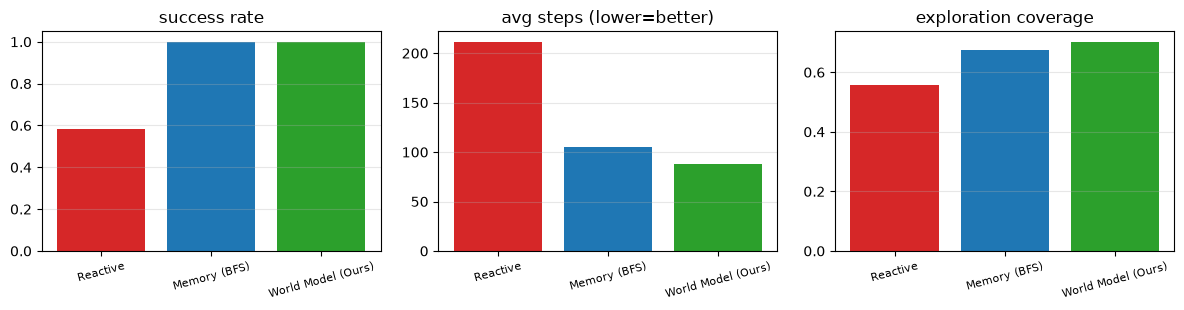

In [12]:
results = {
    "Reactive":            evaluate(lambda seed: ReactiveAgent(seed), test_maps),
    "Memory (BFS)":        evaluate(lambda seed: MemoryAgent(25, 25, R_VIEW, seed), test_maps),
    "World Model (Ours)":  evaluate(lambda seed: WorldModelAgent(25, 25, model, PRIOR_FREE,
                                                                 R_VIEW, seed), test_maps),
}
print(f"{'agent':22s} {'success':>10s} {'avg steps':>10s} {'coverage':>10s}")
summary = {}
for name, rows in results.items():
    succ = np.mean([r["success"] for r in rows])
    steps = np.mean([r["steps"] for r in rows])
    cov = np.mean([r["coverage"] for r in rows])
    summary[name] = (succ, steps, cov)
    print(f"{name:22s} {succ:>10.2f} {steps:>10.1f} {cov:>10.2f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, k, title in zip(axes, range(3), ["success rate", "avg steps (lower=better)",
                                          "exploration coverage"]):
    vals = [summary[n][k] for n in summary]
    ax.bar(range(3), vals, color=["#d62728", "#1f77b4", "#2ca02c"])
    ax.set_xticks(range(3)); ax.set_xticklabels(list(summary), rotation=15, fontsize=8)
    ax.set_title(title); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig("assets/metrics.png", dpi=110); plt.show()

**How to read this table:**

- **Reactive** has a clearly lower success rate and hits the step cap. Not because it is "stupid": under partial observability, no memory means no state, and greedy oscillation in corners is inevitable;
- **Memory** buys a near-perfect success rate with frontier exploration, but at the cost of many steps: it treats the unknown as walls, so however close the goal is, it has to go around along known paths first;
- **World Model** extends planning into unknown areas with the model's guesses: the frontier's "imagined distance" cuts through unknown areas predicted to be open, and once the goal appears it heads straight for it. It reaches the goal in **clearly fewer steps** without lower coverage (exploring more "accurately", not "less"). This is direct evidence that "a model lets planning go beyond the seen region". But this gain rests entirely on how trustworthy the model is; the next section tests it in an OOD world.

### 7.1 Trajectory comparison on the same map

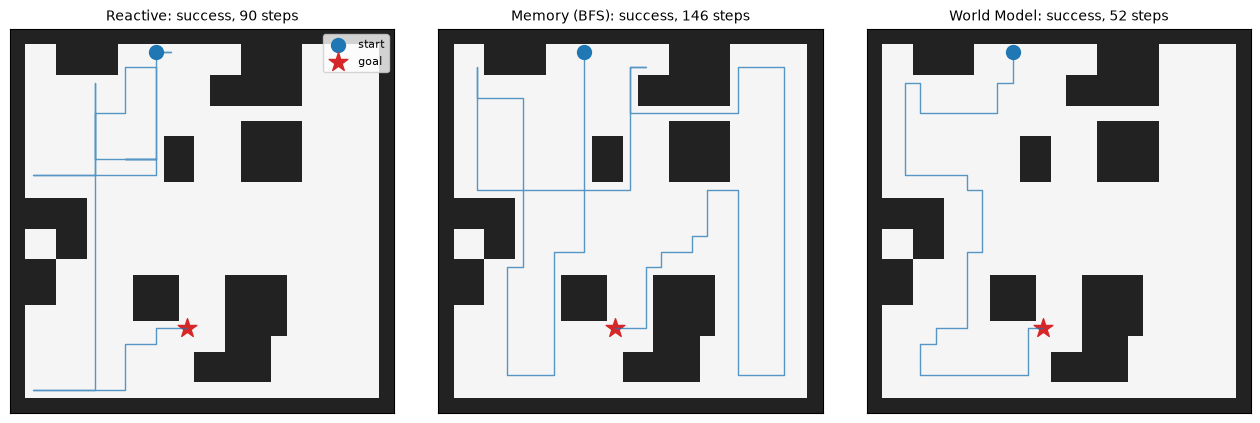

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
g, s, gl = test_maps[0]
for ax, (name, maker) in zip(axes, [
        ("Reactive", lambda seed: ReactiveAgent(seed)),
        ("Memory (BFS)", lambda seed: MemoryAgent(25, 25, R_VIEW, seed)),
        ("World Model", lambda seed: WorldModelAgent(25, 25, model, PRIOR_FREE, R_VIEW, seed))]):
    env = GridNavEnv(g, s, gl, view_radius=R_VIEW, max_steps=300)
    res = run_episode(env, maker(0))
    tr = np.array(res["traj"])
    ax.imshow(g, cmap=mcolors.ListedColormap(["#f5f5f5", "#222222"]))
    ax.plot(tr[:, 1], tr[:, 0], "-", c="#1f77b4", lw=1.0, alpha=0.75)
    ax.scatter(*s[::-1], marker="o", c="#1f77b4", s=100, label="start")
    ax.scatter(*gl[::-1], marker="*", c="#d62728", s=200, label="goal")
    ax.set_title(f"{name}: {'success' if res['success'] else 'FAIL'}, {res['steps']} steps",
                 fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.savefig("assets/agent_paths.png", dpi=110); plt.show()

## 8. Experiment: when the statistics of the world change — the OOD risk of a world model

**Why this experiment:** all of the world model agent's advantage comes from the model's guesses about "the statistical regularities of unseen regions". Our model was trained on maps with **large rectangular obstacles**. What happens if the test world switches to **fine-grained noisy obstacles** (salt-and-pepper, never seen in the training distribution)?

We test at two levels: **the model level** (8.1), the per-cell prediction accuracy of the same forward model on OOD windows; and **the behavior level** (8.2), the task metrics of the memory and world model agents on OOD maps. We expect model accuracy to drop clearly; whether behavior collapses with it depends on whether closed-loop replanning can absorb the model error.

In [14]:
def generate_ood_map(H, W, rng, p_wall=0.22, min_dist=20, max_tries=300):
    """salt-and-pepper noise obstacles: statistically completely different from the rectangular training obstacles (OOD)."""
    for _ in range(max_tries):
        grid = (rng.random((H, W)) < p_wall).astype(np.int64)
        grid[0, :] = grid[-1, :] = 1; grid[:, 0] = grid[:, -1] = 1
        frees = np.argwhere(grid == 0)
        i, j = rng.choice(len(frees), size=2, replace=False)
        s, gl = tuple(frees[i]), tuple(frees[j])
        if abs(s[0] - gl[0]) + abs(s[1] - gl[1]) < min_dist:
            continue
        if _reachable(grid, s, gl):
            return grid, s, gl
    raise RuntimeError("ood map generation failed")

ood_rng = np.random.default_rng(3000)
ood_maps = [generate_ood_map(25, 25, ood_rng) for _ in range(8)]

# --- 8.1 model level: per-cell prediction accuracy of the same forward model after the distribution changes ---
def sample_windows(maps, per_map, R, seed):
    """sample masked (window, STAY) query samples from a given map set and measure in/out-of-distribution accuracy."""
    rng = np.random.default_rng(seed)
    W5, Y = [], []
    for g, _, _ in maps:
        frees = np.argwhere(g == 0)
        for _ in range(per_map):
            r, c = frees[rng.integers(len(frees))]
            w = window_of(g, r, c, R).astype(np.int64)
            w[rng.random(w.shape) < rng.uniform(0.0, 0.6)] = UNKNOWN
            W5.append(w); Y.append(window_of(g, r, c, R))
    return np.array(W5), np.array(Y)

def cell_accuracy(maps, seed):
    W5, Y = sample_windows(maps, 400, R_VIEW, seed)
    x = torch.from_numpy(encode_batch(W5, np.full(len(W5), STAY))).float()
    with torch.no_grad():
        pred = model(x).argmax(dim=1).numpy()
    yf = Y.reshape(len(Y), -1)
    unk = (W5.reshape(len(W5), -1) == UNKNOWN)
    return float((pred == yf).mean()), float((pred[unk] == yf[unk]).mean())

in_rng = np.random.default_rng(4000)
in_dist_maps = [generate_map(25, 25, 14, in_rng, min_dist=20) for _ in range(8)]
a_in = cell_accuracy(in_dist_maps, seed=1)
a_ood = cell_accuracy(ood_maps, seed=2)
print(f"{'distribution':28s} {'overall acc':>12s} {'unseen-cell acc':>16s}")
print(f"{'in-dist (rect obstacles)':28s} {a_in[0]:>12.3f} {a_in[1]:>16.3f}")
print(f"{'OOD (salt-and-pepper)':28s} {a_ood[0]:>12.3f} {a_ood[1]:>16.3f}")
print("→ the model didn't change, the world did: guessing accuracy on 'unseen cells' drops clearly. This is OOD, quantified.")

distribution                  overall acc  unseen-cell acc
in-dist (rect obstacles)            0.957            0.893
OOD (salt-and-pepper)               0.829            0.731
→ the model didn't change, the world did: guessing accuracy on 'unseen cells' drops clearly. This is OOD, quantified.


**Model level: accuracy drops clearly.** The prior of the rectangle world (big connected obstacles, straight edges) does not hold at all in the noisy world, and the model's completion accuracy on unseen cells falls by more than ten points. **A model's "imagination" can only be trusted in the interpolation neighborhood of its training distribution.** This is a general constraint on every learned world model.

### 8.2 Behavior level: is the model error absorbed by closed loop?

agent (OOD test maps)       success  avg steps   coverage
Memory (BFS)                   1.00      118.5       0.73
World Model (OOD)              1.00       87.8       0.64


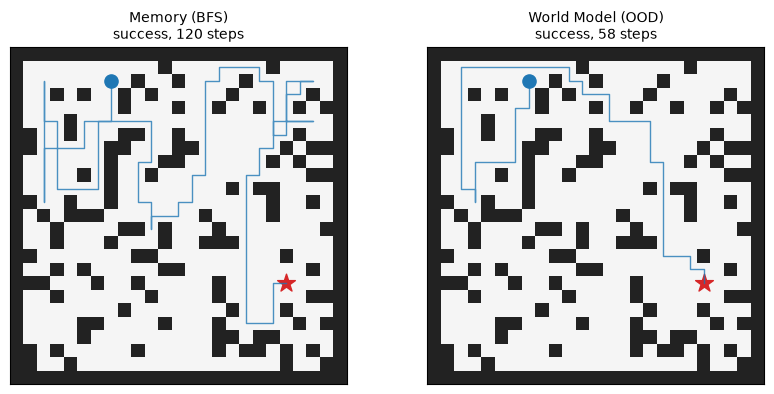

In [15]:
ood_results = {
    "Memory (BFS)":       evaluate(lambda seed: MemoryAgent(25, 25, R_VIEW, seed), ood_maps),
    "World Model (OOD)":  evaluate(lambda seed: WorldModelAgent(25, 25, model, PRIOR_FREE,
                                                                R_VIEW, seed), ood_maps),
}
print(f"{'agent (OOD test maps)':24s} {'success':>10s} {'avg steps':>10s} {'coverage':>10s}")
for name, rows in ood_results.items():
    print(f"{name:24s} {np.mean([r['success'] for r in rows]):>10.2f} "
          f"{np.mean([r['steps'] for r in rows]):>10.1f} "
          f"{np.mean([r['coverage'] for r in rows]):>10.2f}")

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4))
for ax, (name, rows) in zip(axes, ood_results.items()):
    ax.imshow(ood_maps[0][0], cmap=mcolors.ListedColormap(["#f5f5f5", "#222222"]))
    tr = np.array(rows[0]["traj"])
    ax.plot(tr[:, 1], tr[:, 0], "-", c="#1f77b4", lw=1.0, alpha=0.8)
    ax.scatter(*ood_maps[0][1][::-1], marker="o", c="#1f77b4", s=90)
    ax.scatter(*ood_maps[0][2][::-1], marker="*", c="#d62728", s=180)
    ax.set_title(f"{name}\n{'success' if rows[0]['success'] else 'FAIL'}, "
                 f"{rows[0]['steps']} steps", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig("assets/ood_comparison.png", dpi=110); plt.show()

**Typical observation:** even though the model's prediction accuracy gets clearly worse under OOD (8.1), the world model agent's task metrics stay on par with memory, or even better, because **closed-loop replanning** corrects the imagined map with the latest observation at every step, so a wrong guess only costs a few extra steps (consistent with the open vs closed conclusion of Lab 4).

But **don't misread this as "OOD is harmless"**: wrong guesses are cheap in this experiment because the world is not dense and planning is redone every step. In denser worlds, with open-loop execution (the idea of Exercise 3), or in safety-critical settings, the kind of accuracy drop seen in 8.1 turns directly into failure. The standard engineering answer is an **uncertainty-aware model** (ensembles / confidence calibration): when the model is not confident, fall back automatically to memory's conservative planning and trust only what you have seen.

In [16]:
import resource
elapsed = time.time() - T0
peak_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024 / 1024
print(f"total notebook time (up to this cell): {elapsed:.1f} s | peak memory: {peak_mb:.0f} MB | device: CPU")

total notebook time (up to this cell): 21.5 s | peak memory: 1 MB | device: CPU


## 9. Questions

1. How much of the reactive agent's failure comes from "no map" and how much from "no action history (it doesn't even remember which way it went a second ago)"? How much success rate is recovered by giving the reactive agent just one extra input, "the previous action"?
2. The memory agent treats UNKNOWN as impassable (conservative); if UNKNOWN is treated as FREE instead (optimistic, like D* Lite's initial assumption), with no learning at all, can it match the world model agent? Under what map statistics does the optimistic strategy break?
3. After hitting a wall, the world model agent heals itself through closed-loop replanning. If the model's predictions were cached and never updated (open-loop imagination), what would the failure mode become? (Relate to Lab 4's open vs closed comparison.)
4. The odometry in this lab is noise-free. A real robot's wheel odometry drifts, and the map gets ghosting and tearing. That is exactly the problem **SLAM** solves: besides building the map, it corrects the pose estimate **at the same time**.

### ✏️ Exercise 1 — Field of view: quantifying partial observability

Change `R_VIEW` from 2 (5×5) to 1 (3×3) or 3 (7×7) and rerun the comparison in Section 7. Note that `ForwardModel`'s input dimension depends on the window size, so both the dataset and the model have to be rebuilt. How does the gap between the three agents change as the field of view shrinks?

In [17]:
# YOUR CODE HERE
# hint: R_VIEW = 1 → rerun the 3.3 dataset → rebuild ForwardModel(R=1) → retrain → re-evaluate

### ✏️ Exercise 2 — Odometry noise: when the map starts to "drift"

Make the env "slip" with 5% probability: the action has no effect, but `info["moved"]` still reports True (the odometry lies). Subclass `GridNavEnv` and override `step`, then rerun only the memory agent and overlay its final memory map on the ground truth. You will see misalignment and ghosting in the map. This is why VSLAM exists.

In [18]:
# YOUR CODE HERE
# hint: class SlipperyEnv(GridNavEnv): use self.rng inside step to decide whether this step slips

### ✏️ Exercise 3 — Bigger maps + moving obstacles

Enlarge the map to 41×41 and add 2 dynamic obstacles to the env that random-walk every step (they block the agent on contact). The memory map's "seen means true" assumption fails in a dynamic world, so the map needs "forgetting" or timestamps. Think: can a world model learn to predict how obstacles move? How does this connect to the video prediction lab?

In [19]:
# YOUR CODE HERE

## 10. Takeaways

- **Partial observability is the first-principles problem of navigation**: when the current observation is not enough to decide, the agent has to compress history into an internal state. That is state estimation;
- **Memory (an occupancy map) is already a form of spatial intelligence**: it turns an episodic stream of observations into a persistent allocentric structure and makes graph planning such as BFS/A* possible; frontier exploration + conservative planning is enough for a near-perfect success rate;
- **A world model lets planning go beyond the seen region**: occupancy predictions for unknown cells → an imagined cost map → shortcuts and smarter frontier choices. The gain is fewer steps; the price is model error;
- **Model error can be corrected in closed loop and is amplified under OOD**: when the statistics of the world change, the model's confident guesses become systematic errors, and conservative memory is actually more stable. An uncertainty-aware model is the standard answer;
- **This lab's chain, Observation → State Estimation → Memory/Map → World Model → Planning → Action, is a minimal 2D-grid implementation of cognitive mapping, Active Neural SLAM and the Dreamer family.** Next (Lab 9): replace planning with a learned policy, and the world model starts supplying imagined data for policy training.